# YRBS 2007 Final Project: Sleep, Screen Time, and BMI Percentile

This notebook reproduces the final project workflow: research question, data cleaning, ANOVA, weighted regression, figures, and interpretation.

## Research Question

Are sleep duration and lifestyle behaviors associated with BMI percentile among U.S. high school students in the 2007 National Youth Risk Behavior Survey?

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.append(str(ROOT / 'scripts'))

import build_project
clean, analysis = build_project.load_and_clean()
models = build_project.fit_models(analysis)
tables = build_project.build_tables(clean, analysis, models)
figure_paths = build_project.create_figures(analysis, tables, models)
summary_paths = build_project.create_infographic(tables, models, figure_paths)
analysis.shape

(11256, 18)

## Variables and Cleaning

In [2]:
tables['variable_dictionary']

,analysis_variable,source_column,definition
0,bmi_pct,BMIPCT,BMI percentile based on CDC age-sex growth cha...
1,sleep_group,Sleep / Q97,"<=6 hours, 7 hours, or 8+ hours on an average ..."
2,physical_activity_days,PhysicalActivity5OrMoreDays / Q80,Days in the past 7 days with at least 60 minut...
3,tv_hours,TelevisionWatching / Q81,Approximate TV hours on an average school day;...
4,computer_hours,ComputerUse / Q82,Approximate non-school computer/video game hou...
5,sex,WhatIsYourSex / Q2,"1 = Female, 2 = Male."
6,grade,InWhatGradeAreYou / Q3,9th through 12th grade; ungraded/other exclude...


## Descriptive Results

In [3]:
tables['sample_summary']

tables['sleep_group_summary'].round(2)

,sleep_group,n,percent,bmi_mean,bmi_sd,bmi_median,weighted_bmi_mean,mean_screen_time_hours,mean_physical_activity_days
0,<=6 hours,4383.0,38.94,66.01,27.49,71.98,64.38,3.94,2.86
1,7 hours,3377.0,30.00,65.02,26.69,69.53,63.84,3.70,3.11
2,8+ hours,3496.0,31.06,64.38,28.06,70.78,63.05,3.61,3.20


## ANOVA

In [4]:
tables['anova_sleep_group'].round(4)
print(f"One-way ANOVA p-value: {models['anova_p']:.4f}")

One-way ANOVA p-value: 0.0292


## Weighted Regression

In [5]:
coef = tables['model_coefficients']
coef[coef['model'].eq('WLS survey weight robust HC3')].round(4)

,term,estimate,robust_se,p_value,ci_low,ci_high,model
10,Intercept,57.4053,1.1419,0.0000,55.1673,59.6433,WLS survey weight robust HC3
11,"C(sleep_group, Treatment(reference=""8+ hours"")...",2.3619,0.8429,0.0051,0.7098,4.0141,WLS survey weight robust HC3
12,"C(sleep_group, Treatment(reference=""8+ hours"")...",1.3206,0.8606,0.1249,-0.3661,3.0073,WLS survey weight robust HC3
13,"C(sex, Treatment(reference=""Female""))[T.Male]",3.6238,0.7009,0.0000,2.2501,4.9975,WLS survey weight robust HC3
14,"C(grade, Treatment(reference=""10th grade""))[T....",1.4552,0.9492,0.1253,-0.4052,3.3157,WLS survey weight robust HC3
15,"C(grade, Treatment(reference=""10th grade""))[T....",-0.5348,0.9493,0.5732,-2.3953,1.3257,WLS survey weight robust HC3
16,"C(grade, Treatment(reference=""10th grade""))[T....",-2.2790,0.9697,0.0188,-4.1795,-0.3785,WLS survey weight robust HC3
17,physical_activity_days,-0.0721,0.1331,0.5880,-0.3330,0.1888,WLS survey weight robust HC3
18,tv_hours,2.1607,0.2233,0.0000,1.7229,2.5984,WLS survey weight robust HC3
19,computer_hours,-0.4644,0.2394,0.0524,-0.9335,0.0047,WLS survey weight robust HC3


## Figures

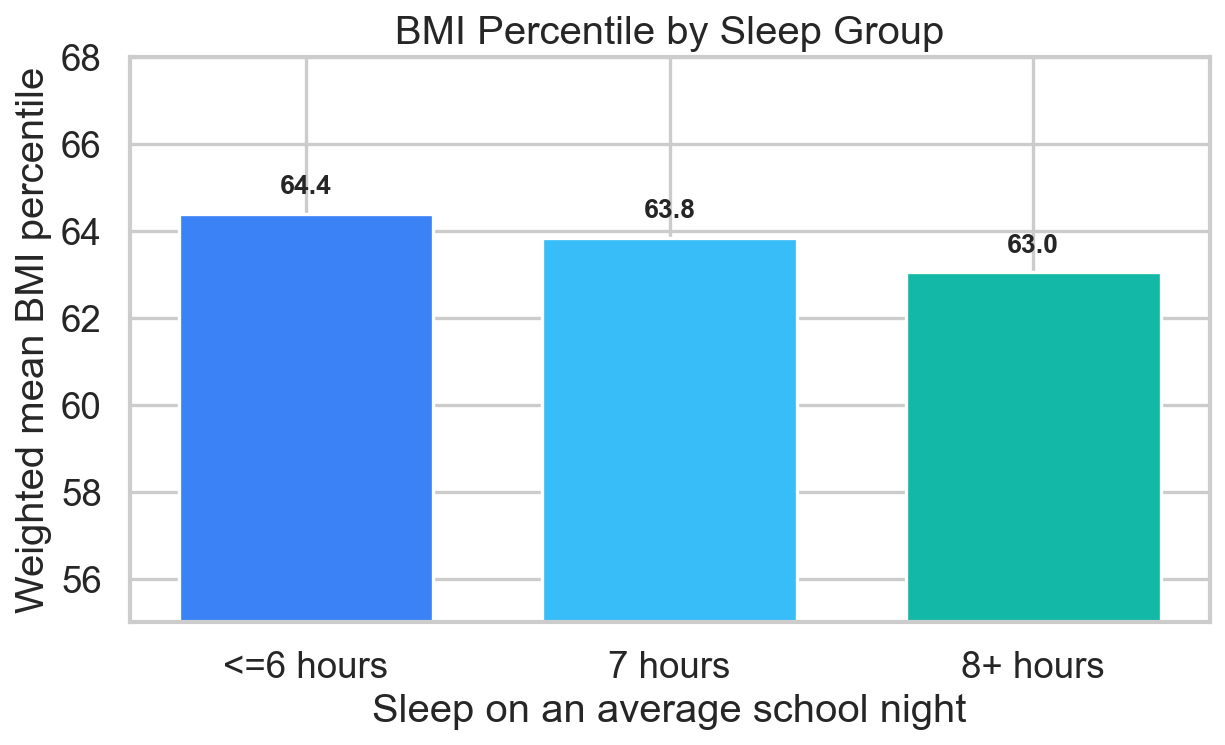

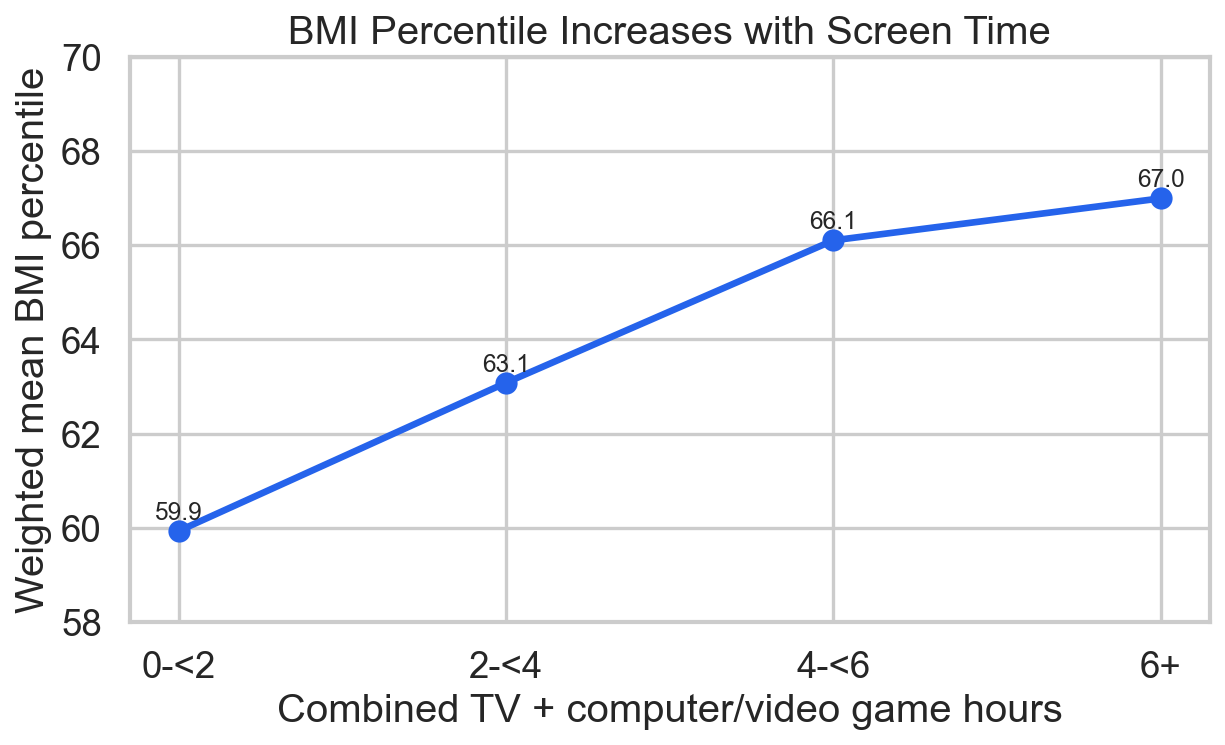

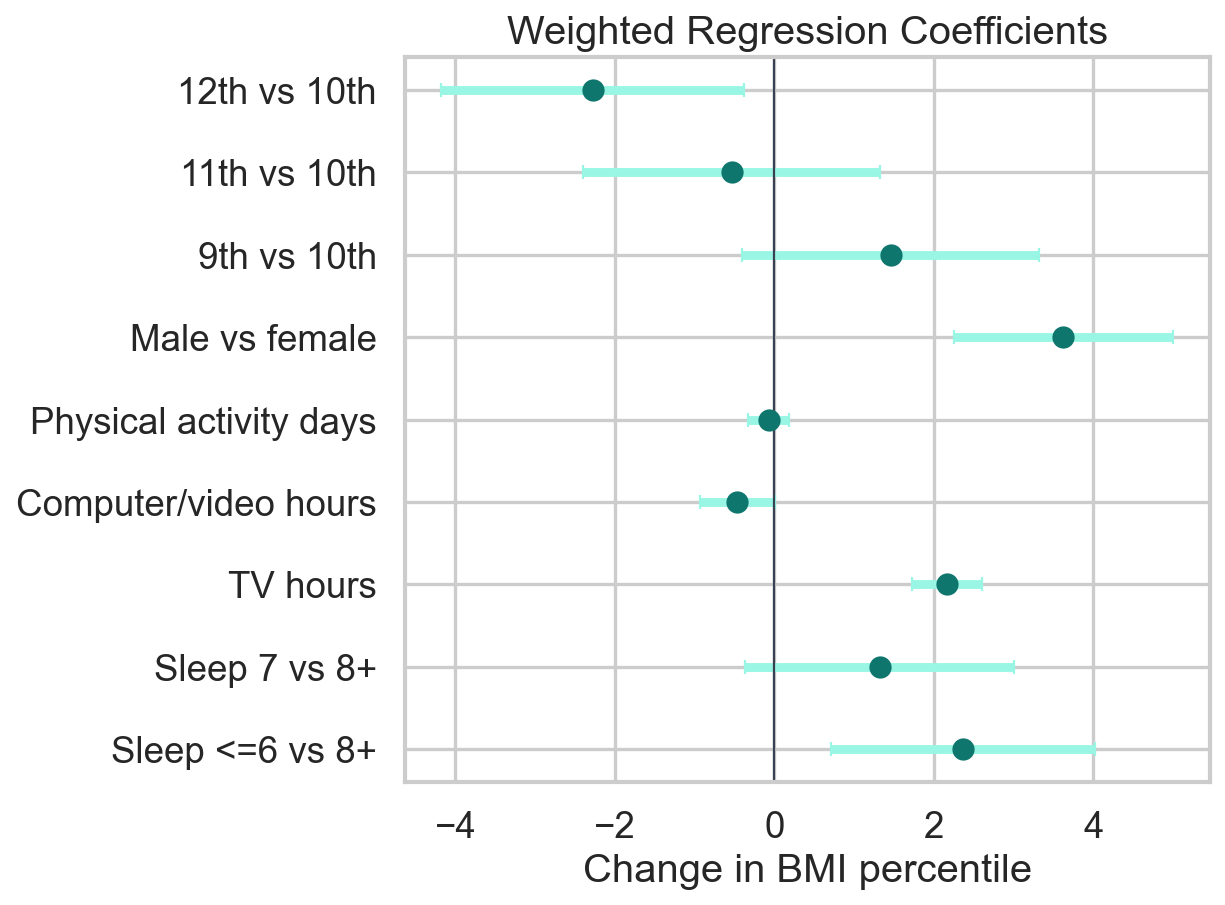

In [6]:
from IPython.display import Image, display

display(Image(filename=str(figure_paths['bmi_by_sleep_group'])))
display(Image(filename=str(figure_paths['bmi_by_screen_time'])))
display(Image(filename=str(figure_paths['weighted_regression_coefficients'])))

## Conclusion

Students reporting <=6 hours of sleep had a higher BMI percentile than students reporting 8+ hours, after adjusting for TV time, computer/video game time, physical activity, sex, and grade. TV time was also positively associated with BMI percentile. These are associations in a cross-sectional survey, so they should not be interpreted as causal effects.